In [1]:
# 1. SETUP ENVIRONMENT
# We need to install the 'wfdb' package to read PhysioNet files

!pip install wfdb

import wfdb
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:

# ==========================================
# 2. DATA ACQUISITION
# ==========================================
# Since PTB-XL is large, we will download just ONE record for demonstration.
# We need the header (.hea) and the signal (.dat) files.

print("Downloading sample ECG data...")

# Create a data directory
os.makedirs('data', exist_ok=True)

# Download a sample record (Patient 00001) from PhysioNet
!wget -q -O data/00001_lr.dat https://physionet.org/files/ptb-xl/1.0.3/records100/00000/00001_lr.dat
!wget -q -O data/00001_lr.hea https://physionet.org/files/ptb-xl/1.0.3/records100/00000/00001_lr.hea

print("Download complete.")

Download complete.


In [4]:
# ==========================================
# 3. LOADING THE SIGNAL (Student Section)
# ==========================================

# Define the path to the record (without extension)
record_path = 'data/00001_lr'

# Read sample
signals, fields = wfdb.rdsamp(record_path)

# Inspect the data
print(f"Sampling Frequency: {fields['fs']} Hz")
print(f"Signal Shape: {signals.shape}") # Should be (Samples, 12 Leads)
print(f"Leads available: {fields['sig_name']}")

Sampling Frequency: 100 Hz
Signal Shape: (1000, 12)
Leads available: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


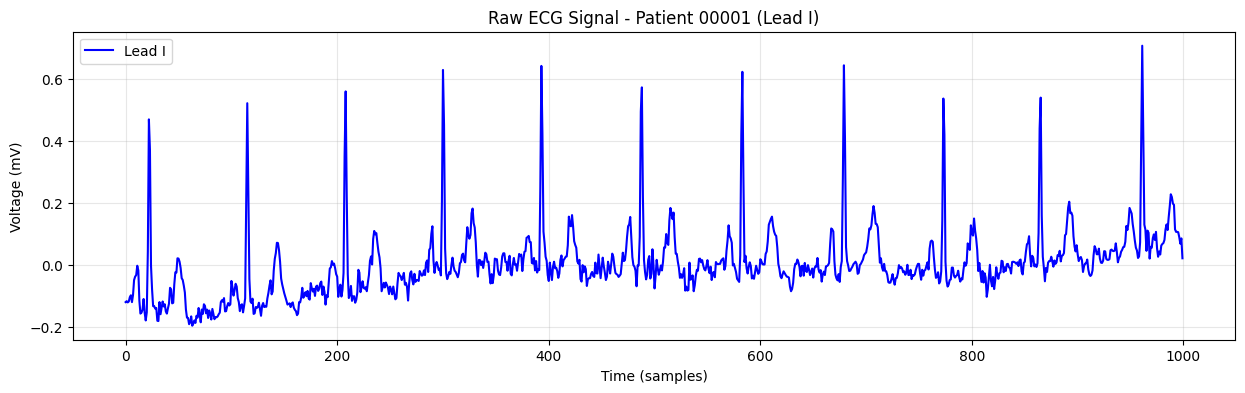

In [5]:
# ==========================================
# 4. VISUALIZATION
# ==========================================
# Let's plot the first 1000 samples of Lead I (index 0)

plt.figure(figsize=(15, 4))

plt.plot(signals[:1000, 0], color='blue', label='Lead I')

plt.title("Raw ECG Signal - Patient 00001 (Lead I)")
plt.xlabel("Time (samples)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()